# <span style="color:red">  Daily Data - EBC creation, FMB Quantiles

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

PROJECT_ROOT = Path.cwd().resolve().parents[0]
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"


In [3]:
import importlib
import src.preference_factors.build_datasets as bd
import src.FamaMacBeth.betas as fmb_betas
import src.FamaMacBeth.pipeline as fmb_pipe
import src.FamaMacBeth.quantile as fmb_quantile
import src.FamaMacBeth.cross_sectional_regression as fmb_csr
import src.FamaMacBeth.pricing as fmb_pricing
import src.FamaMacBeth.backtest as fmb_backtest
import src.FamaMacBeth.plots as fmb_plots

# Reload the modules themselves
importlib.reload(bd)
importlib.reload(fmb_betas)
importlib.reload(fmb_pipe)
importlib.reload(fmb_quantile)
importlib.reload(fmb_csr)
importlib.reload(fmb_pricing)
importlib.reload(fmb_backtest)
importlib.reload(fmb_plots)


<module 'src.FamaMacBeth.plots' from '/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/plots.py'>

# <span style="color:red"> Create CSV's for Daily EBC Weights, Beta Contributions, EBC returns, Preference Returns, Full preference and factors returns (Excess returns) </span>

In [5]:
merged_df, full_merged_df = bd.build_all_dataset(
    returns_file="sp500_returns_daily_with_tickers.csv",
    market_caps_file="sp500_market_caps_daily.csv",
    ff_factors_file="ff_factors_daily.csv",
    frequency="daily"
)

ebc = merged_df["EBC"]
cw_ebc = merged_df["CW-EBC"]


Rolling OLS CAPM:   0%|          | 0/15229 [00:00<?, ?it/s]

EBC optimization (parallel):   0%|          | 0/15229 [00:00<?, ?it/s]

/Users/evi/Desktop/Invesco_Research_Project/src/preference_factors/build_EBC.py:292: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  weights_rebal = full_weights.resample("M").last()


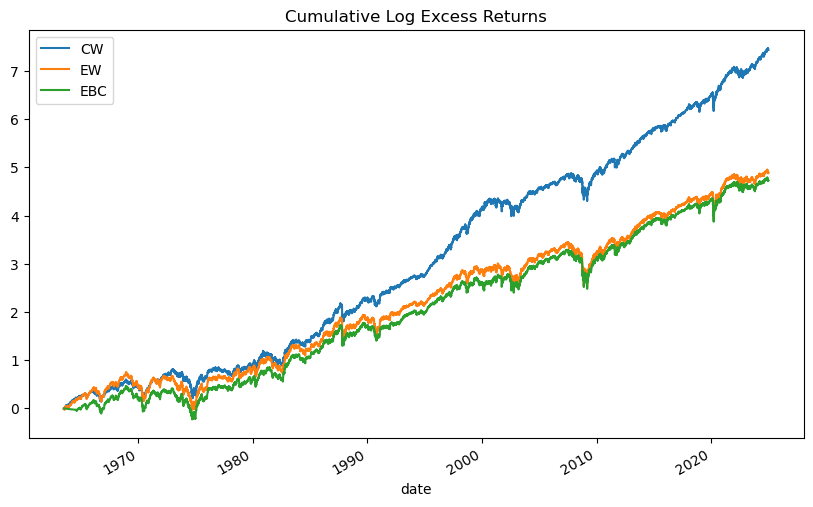

In [6]:
np.log1p(merged_df[['CW', 'EW', 'EBC']]).cumsum().plot(figsize=(10,6))
plt.title("Cumulative Log Excess Returns")
plt.show()

# <span style="color:red">  Get rolling betas for the two focus portfolios EBC and CW - EBC

#### create factor returns

In [7]:
ebc = ebc.to_frame(name="EBC")
cw_ebc = cw_ebc.to_frame(name="CW-EBC")
factor_returns =  pd.concat([ebc, cw_ebc], axis=1).dropna()
factor_returns.columns = ["EBC", "CW-EBC"]

#### get asset returns and make them excess

In [8]:
asset_returns = bd.build_returns_dataset("sp500_returns_daily_with_tickers.csv", frequency="daily")
ff_factors = bd.build_ff_dataset("ff_factors_daily.csv", frequency="daily")

asset_returns, ff_factors = asset_returns.align(ff_factors, join="inner", axis=0)
# Create the Excess Returns for the Assets
asset_excess_returns = asset_returns.sub(ff_factors["RF"], axis=0)

#### compute rolling betas for EBC and CW-EBC

In [9]:
asset_excess_returns, factor_returns = asset_excess_returns.align(factor_returns, join="inner", axis=0)

betas_ebc = fmb_betas.compute_rolling_betas(asset_excess_returns, ebc, rolling_window=252, min_obs=100)
betas_cw_ebc = fmb_betas.compute_rolling_betas(asset_excess_returns, cw_ebc, rolling_window=252, min_obs=100)


Estimating rolling betas: 100%|██████████| 15229/15229 [19:02<00:00, 13.33it/s]
/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/betas.py:72: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = betas_df.stack(dropna=True)
Estimating rolling betas: 100%|██████████| 15229/15229 [16:24<00:00, 15.47it/s]
/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/betas.py:72: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = betas_df.stack(dropna=True)


### CHECKS

In [10]:
print("EBC betas shape:", betas_ebc.shape)
print("CW-EBC betas shape:", betas_cw_ebc.shape)

print("\nFirst 5 rows:")
print(betas_ebc.head())

EBC betas shape: (15229, 1969)
CW-EBC betas shape: (15229, 1969)

First 5 rows:
                   A        AA  AAF  AAL  AAP  AAPL       ABA  ABBV  ABC  \
date                                                                       
1964-07-01  2.728661  2.728661  NaN  NaN  NaN   NaN  0.103030   NaN  NaN   
1964-07-02  2.728661  2.728661  NaN  NaN  NaN   NaN  0.103030   NaN  NaN   
1964-07-06  2.728661  2.728661  NaN  NaN  NaN   NaN  0.908632   NaN  NaN   
1964-07-07  2.728661  2.728661  NaN  NaN  NaN   NaN  1.963803   NaN  NaN   
1964-07-08  2.728661  2.728661  NaN  NaN  NaN   NaN  1.793077   NaN  NaN   

                 ABG  ...        ZA        ZB  ZBH  ZBRA        ZE  ZION  ZMH  \
date                  ...                                                       
1964-07-01  2.728661  ...  0.524145  0.103030  NaN   NaN  2.728661   NaN  NaN   
1964-07-02  2.728661  ...  0.442863  1.138504  NaN   NaN  2.728661   NaN  NaN   
1964-07-06  2.728661  ...  0.103030  1.713419  NaN   NaN  2.728

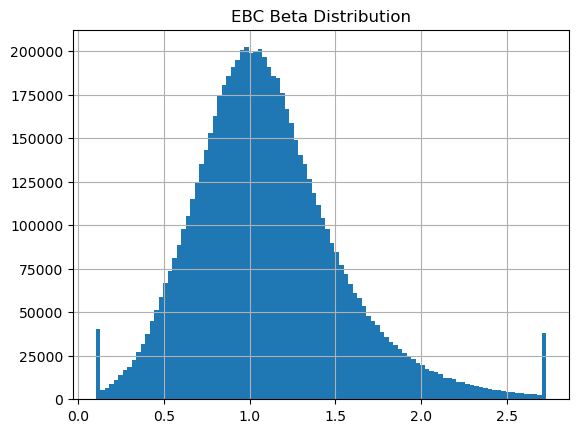

In [11]:
betas_ebc.stack().hist(bins=100)
plt.title("EBC Beta Distribution")
plt.show()

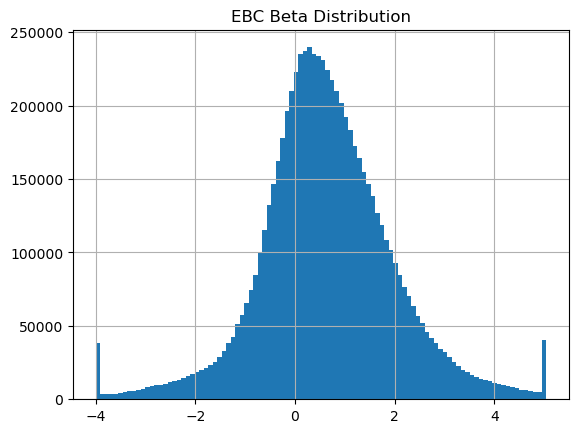

In [12]:
betas_cw_ebc.stack().hist(bins=100)
plt.title("EBC Beta Distribution")
plt.show()

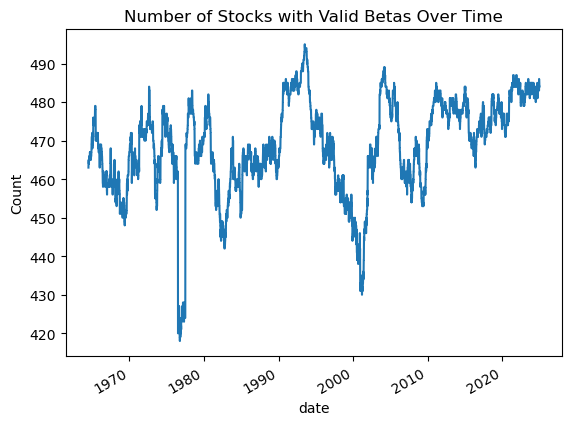

In [13]:
# Count how many stocks have a valid beta each month
betas_ebc.count(axis=1).plot(title="Number of Stocks with Valid Betas Over Time")
plt.ylabel("Count")
plt.show()

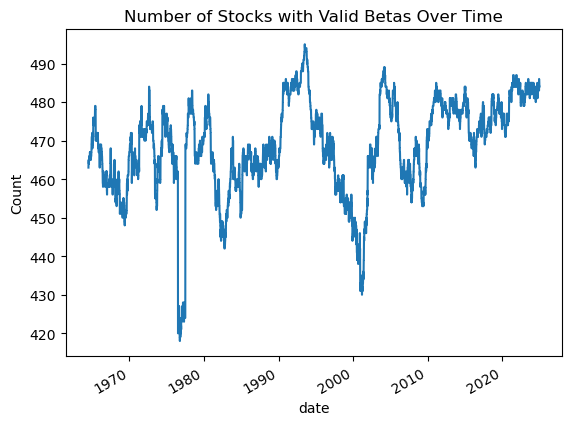

In [14]:
# Count how many stocks have a valid beta each month
betas_cw_ebc.count(axis=1).plot(title="Number of Stocks with Valid Betas Over Time")
plt.ylabel("Count")
plt.show()

# <span style="color:red">  Run full factor pipeline --> Two factor regressions FMB

In [19]:
start_date = "1969-12-01"

In [20]:
asset_excess_returns_trimmed = asset_excess_returns.loc[start_date:]
factor_returns_trimmed = factor_returns.loc[start_date:]
betas_ebc_trimmed = betas_ebc.loc[start_date:]
betas_cw_ebc_trimmed = betas_cw_ebc.loc[start_date:]

In [21]:
results = fmb_pipe.run_full_factor_pipeline(
    beta1_df=betas_ebc_trimmed,
    beta2_df=betas_cw_ebc_trimmed,
    sp500=asset_excess_returns_trimmed,
    EBC=factor_returns_trimmed["EBC"],
    Cap_EBC=factor_returns_trimmed["CW-EBC"],
    n_q1=3,
    n_q2=3,
    min_assets_per_cell=3,
    f1_name="EBC",
    f2_name="CW-EBC",
    frequency = 'daily',
    formation_frequency='monthly'
)

results["mean_grid"]

forming portfolios (monthly): 100%|██████████| 661/661 [00:33<00:00, 19.56it/s]
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/tsatools.py:162: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  x = pd.concat(x[::order], axis=1)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/tsatools.py:162: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  x = pd.concat(x[::order], axis=1)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/tsatools.py:162: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a

,1,2,3
1,0.000386,0.000434,0.000505
2,0.000338,0.000374,0.000421
3,0.000314,0.000338,0.000354


In [22]:
results["portrets_wide"][:5]

,Q1_Q1,Q1_Q2,Q1_Q3,Q2_Q1,Q2_Q2,Q2_Q3,Q3_Q1,Q3_Q2,Q3_Q3
date,,,,,,,,,
1970-01-02,0.035489,0.025655,0.028024,0.010921,0.009974,0.021260,0.012058,0.016316,0.013460
1970-01-05,0.006151,0.010083,0.013305,0.002790,0.009125,0.014846,0.011732,0.017208,0.013027
1970-01-06,-0.020506,-0.005940,-0.010196,-0.006364,-0.006641,-0.009144,-0.005491,-0.006289,-0.001730
1970-01-07,-0.000140,-0.000007,0.002070,-0.002615,-0.001370,-0.005020,-0.005063,-0.002098,0.000595
1970-01-08,-0.003006,-0.000195,-0.002067,0.003318,-0.001492,0.000395,0.001262,-0.002140,0.002142


# <span style="color:red">  Backtest

In [23]:
# ============================
# USER PARAMETERS
# ============================
#start_date = "1970-01-01"

# ============================
# REQUIRED INPUTS FROM PIPELINE
# ============================
members_df = results["members"]
n_q1, n_q2 = results["mean_grid"].shape

# ============================
# LOAD RETURNS / CAPS / RF
# ============================
DATA_RAW_DIR = Path.cwd().parent / "data" / "raw"
sp_500, sp_caps, rf = fmb_backtest.load_daily_inputs(DATA_RAW_DIR)  # excess sp500

In [24]:
# ============================
# RUN BACKTEST
# ============================
quantile_portfolios_returns = fmb_backtest.backtest_quantile_portfolios(
    members_df=members_df,
    returns_df=sp_500,
    caps_df=sp_caps,
    n_q1=n_q1,
    n_q2=n_q2,
    weight="cap",
    frequency='daily'
)

Q1 buckets:   0%|          | 0/3 [00:00<?, ?it/s]

In [25]:
quantile_portfolios_returns

,Q1_Q1,Q1_Q2,Q1_Q3,Q2_Q1,Q2_Q2,Q2_Q3,Q3_Q1,Q3_Q2,Q3_Q3
date,,,,,,,,,
1970-01-05,0.001430,0.003380,0.007411,0.004549,0.002509,0.007698,0.007125,0.012491,0.008661
1970-01-06,-0.015995,-0.010487,-0.009853,-0.006757,-0.006765,-0.010219,-0.003432,-0.009193,-0.005744
1970-01-07,-0.006527,-0.002834,-0.004237,-0.001626,-0.002124,-0.002754,-0.000542,-0.001677,0.002062
1970-01-08,-0.002461,0.000697,0.000501,0.002245,-0.000453,0.001596,-0.001674,-0.001490,0.002952
1970-01-09,-0.002821,-0.002903,-0.005363,-0.004471,-0.005842,-0.002563,-0.000581,0.000609,0.001804
...,...,...,...,...,...,...,...,...,...
2024-12-24,0.030022,0.013532,0.009155,0.013209,0.009052,0.006060,0.009277,0.005499,0.003045
2024-12-26,-0.000614,0.002328,0.003686,-0.003622,0.001804,0.000125,-0.001268,0.001415,0.000150
2024-12-27,-0.020480,-0.009142,-0.007605,-0.011481,-0.005243,-0.005873,-0.013888,-0.003267,-0.001894


In [29]:
sp_caps.loc["1970-01-02"]

A        673117.5
AA      1537464.5
AAF           NaN
AAL           NaN
AAP           NaN
          ...    
ZION          NaN
ZMH           NaN
ZRN           NaN
ZTS           NaN
ZY            NaN
Name: 1970-01-02 00:00:00, Length: 1985, dtype: float64

In [56]:
rename_map = {
    "Q1_Q1": "EBC_High_Pref_High",
    "Q1_Q2": "EBC_High_Pref_Mid",
    "Q1_Q3": "EBC_High_Pref_Low",
    "Q2_Q1": "EBC_Mid_Pref_High",
    "Q2_Q2": "EBC_Mid_Pref_Mid",
    "Q2_Q3": "EBC_Mid_Pref_Low",
    "Q3_Q1": "EBC_Low_Pref_High",
    "Q3_Q2": "EBC_Low_Pref_Mid",
    "Q3_Q3": "EBC_Low_Pref_Low",
}

quantile_portfolios_returns = quantile_portfolios_returns.rename(columns=rename_map)


# <span style="color:red"> PLOTS

In [57]:
complete_df = full_merged_df.join(
    quantile_portfolios_returns,
    how="inner"
)


In [58]:
selected_columns = ['CW','EBC_High_Pref_High', 'EBC_High_Pref_Mid',
       'EBC_High_Pref_Low', 'EBC_Mid_Pref_High', 'EBC_Mid_Pref_Mid',
       'EBC_Mid_Pref_Low', 'EBC_Low_Pref_High', 'EBC_Low_Pref_Mid',
       'EBC_Low_Pref_Low']

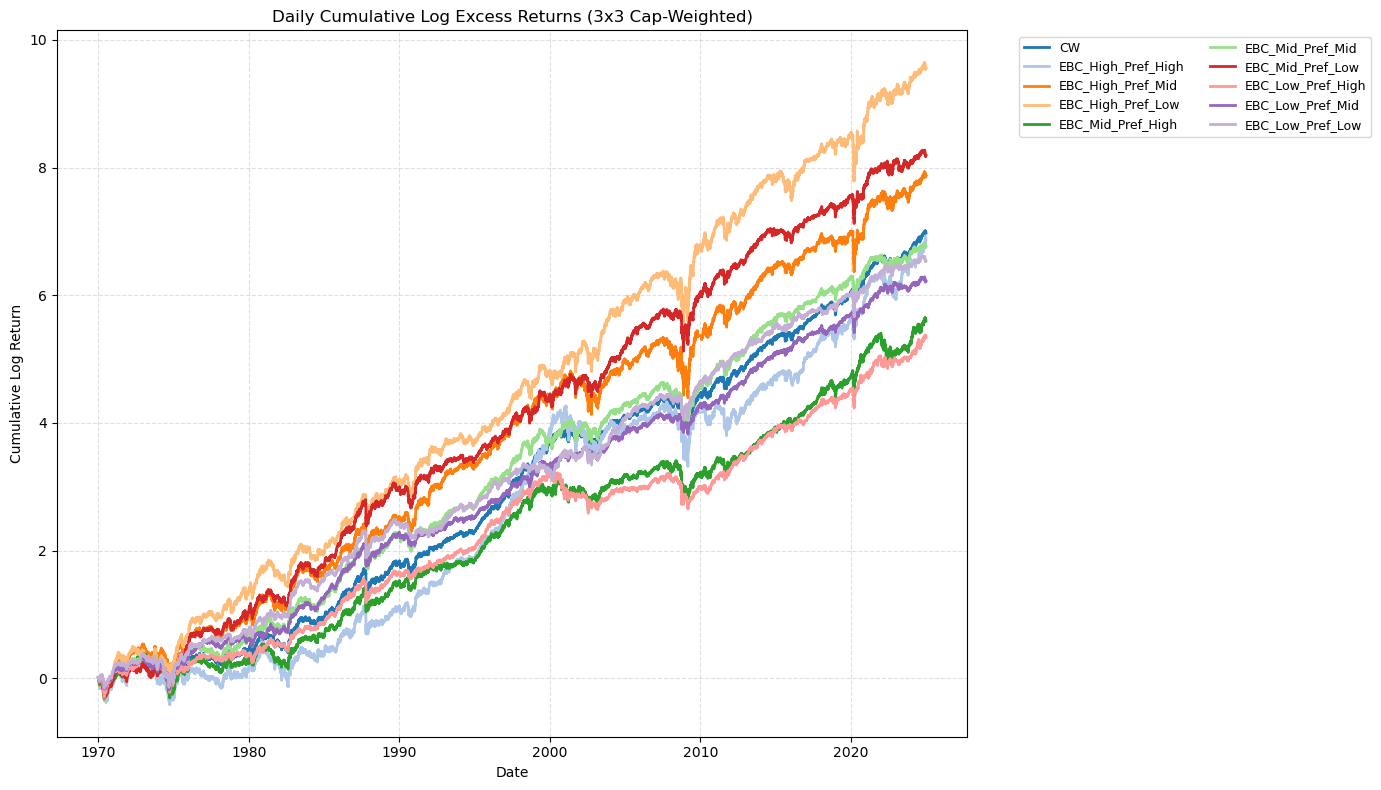

In [59]:
# ============================
# PLOTS
# ============================
fmb_plots.plot_cum_log_returns(
    complete_df[selected_columns],
    title=f"Daily Cumulative Log Excess Returns ({n_q1}x{n_q2} Cap-Weighted)",
)

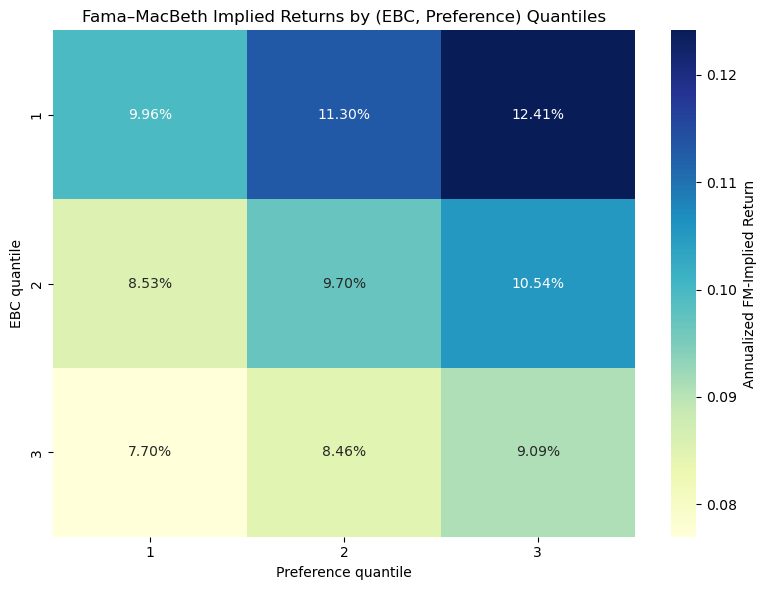

In [60]:
# FM expected-return grid (annualized %)
implied_returns = fmb_plots.plot_expected_return_grid(results["pricing"], results["fm_table"], n_q1, n_q2,frequency='daily')

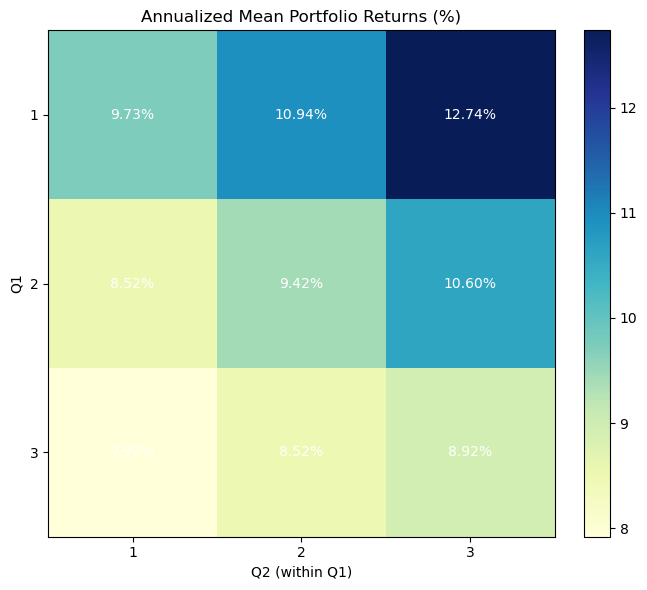

In [61]:
actual_returns = fmb_plots.plot_mean_grid(results["mean_grid"], annualize=True, frequency='daily')

# <span style="color:red"> Save Files

In [68]:

DATA_PROCESSED_DIR_KEN = PROJECT_ROOT / "data" / "processed" / "Ken"

period = start_date[:4] + '_2024'
period

'1969_2024'

## Save implied daily returns

In [69]:
implied_returns_renamed = implied_returns

implied_returns_renamed = implied_returns_renamed.rename(
    index={
        1: "High EBC",
        2: "Medium EBC",
        3: "Low EBC"
    },
    columns={
        1: "High Preference",
        2: "Medium Preference",
        3: "Low Preference"
    }
)

implied_returns_renamed.to_csv(DATA_PROCESSED_DIR_KEN/ f"daily_{period}_implied_returns.csv")

## Save actual daily returns


In [70]:
actual_returns_renamed = actual_returns

actual_returns_renamed = actual_returns_renamed.rename(
    index={
        1: "High EBC",
        2: "Medium EBC",
        3: "Low EBC"
    },
    columns={
        1: "High Preference",
        2: "Medium Preference",
        3: "Low Preference"
    }
)

actual_excel = actual_returns_renamed / 100

actual_excel.to_csv(DATA_PROCESSED_DIR_KEN/ f"daily_{period}_actual_returns.csv")



In [71]:
quantile_portfolios_returns_copy = quantile_portfolios_returns.copy()

save_dir = DATA_PROCESSED_DIR / 'daily'

quantile_portfolios_returns_copy.to_csv(save_dir / f"daily_{period}_quantile_returns_3x3.csv")

# <span style="color:red"> Extra Stats

In [91]:
# 1. Annualized Sharpe Ratio (Daily)
# We use 252 for daily and 12 for monthly
daily_rets = quantile_portfolios_returns
sharpe = (daily_rets.mean() / daily_rets.std()) * np.sqrt(252)

# 2. Maximum Drawdown
# Calculate cumulative growth from $1
cum_rets = (1 + daily_rets).cumprod()
running_max = cum_rets.cummax()
drawdown = (cum_rets - running_max) / running_max
max_dd = drawdown.min()

performance = pd.DataFrame({
    "Ann. Return (%)": daily_rets.mean() * 252 * 100,
    "Ann. Volatility (%)": daily_rets.std() * np.sqrt(252) * 100,
    "Sharpe Ratio": sharpe,
    "Max Drawdown (%)": max_dd * 100
})

# Display sorted by Sharpe to see the most efficient portfolio
print("Portfolio Risk-Reward Summary:")
display(performance.sort_values("Sharpe Ratio", ascending=False).round(3))

Portfolio Risk-Reward Summary:


,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Max Drawdown (%)
EBC_Low_Pref_Low,12.261,13.332,0.920,-39.599
EBC_Mid_Pref_Low,15.828,17.438,0.908,-48.501
EBC_Low_Pref_Mid,11.333,12.684,0.893,-42.837
EBC_High_Pref_Low,19.385,22.985,0.843,-57.068
EBC_Mid_Pref_Mid,13.454,16.690,0.806,-53.954
EBC_High_Pref_Mid,16.631,22.974,0.724,-61.203
EBC_Low_Pref_High,9.979,14.807,0.674,-49.573
EBC_Mid_Pref_High,11.382,18.524,0.614,-50.045
EBC_High_Pref_High,15.558,26.033,0.598,-63.502


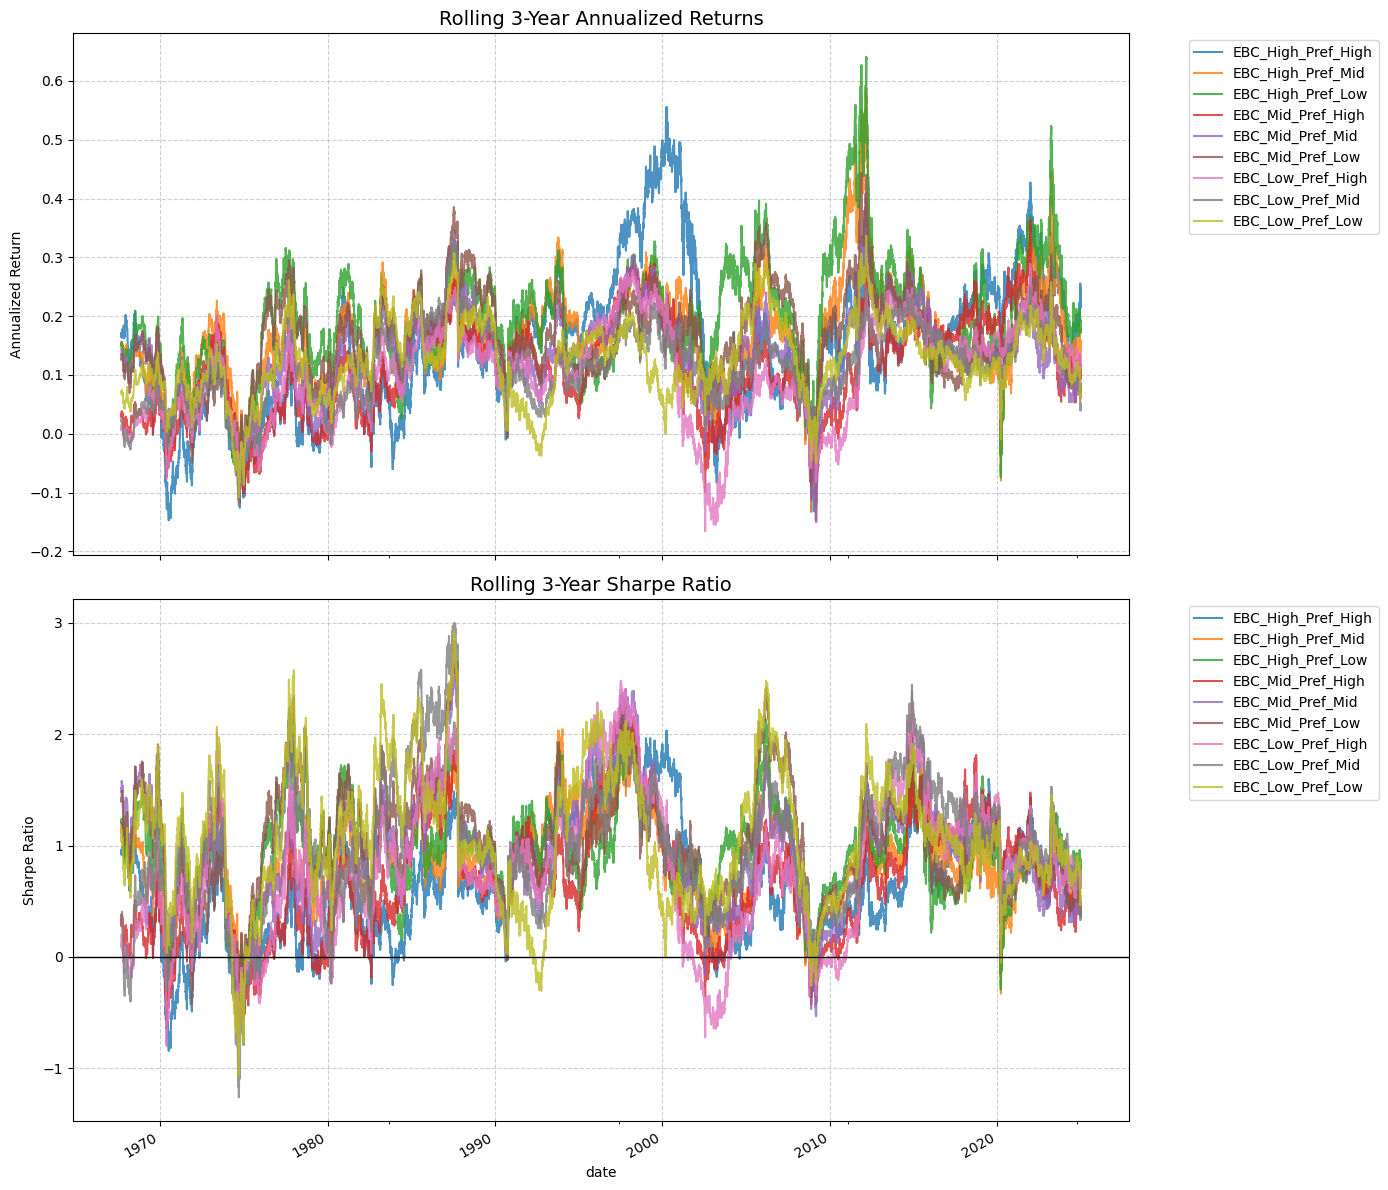

In [92]:
import matplotlib.pyplot as plt

# Define window (252 days * 3 years)
window = 252 * 3 

# 1. Rolling Annualized Returns
rolling_ann_ret = daily_rets.rolling(window=window).mean() * 252

# 2. Rolling Annualized Volatility
rolling_ann_vol = daily_rets.rolling(window=window).std() * np.sqrt(252)

# 3. Rolling Sharpe Ratio
rolling_sharpe = rolling_ann_ret / rolling_ann_vol

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Plot Returns
rolling_ann_ret.plot(ax=ax1, alpha=0.8)
ax1.set_title(f'Rolling {window//252}-Year Annualized Returns', fontsize=14)
ax1.set_ylabel('Annualized Return')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot Sharpe
rolling_sharpe.plot(ax=ax2, alpha=0.8)
ax2.set_title(f'Rolling {window//252}-Year Sharpe Ratio', fontsize=14)
ax2.set_ylabel('Sharpe Ratio')
ax2.axhline(0, color='black', lw=1) # Zero line for reference
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [93]:
from pathlib import Path
PROJECT_ROOT = Path.cwd().resolve().parents[0]
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

In [99]:
selected_columns

['CW',
 'EBC_High_Pref_High',
 'EBC_High_Pref_Mid',
 'EBC_High_Pref_Low',
 'EBC_Mid_Pref_High',
 'EBC_Mid_Pref_Mid',
 'EBC_Mid_Pref_Low',
 'EBC_Low_Pref_High',
 'EBC_Low_Pref_Mid',
 'EBC_Low_Pref_Low']

In [100]:
complete_df[selected_columns].rolling(252).corr()['CW'].loc['1990-01-01':]

date                          
1990-01-02  CW                    1.000000
            EBC_High_Pref_High    0.975500
            EBC_High_Pref_Mid     0.951206
            EBC_High_Pref_Low     0.941041
            EBC_Mid_Pref_High     0.978977
                                    ...   
2024-12-31  EBC_Mid_Pref_Mid      0.697433
            EBC_Mid_Pref_Low      0.465073
            EBC_Low_Pref_High     0.899915
            EBC_Low_Pref_Mid      0.388387
            EBC_Low_Pref_Low      0.219396
Name: CW, Length: 88170, dtype: float64

In [95]:
temp_df = complete_df[selected_columns].rolling(252).corr().loc[:,'EBC_High_Pref_Low'].reset_index()

<Axes: xlabel='date'>

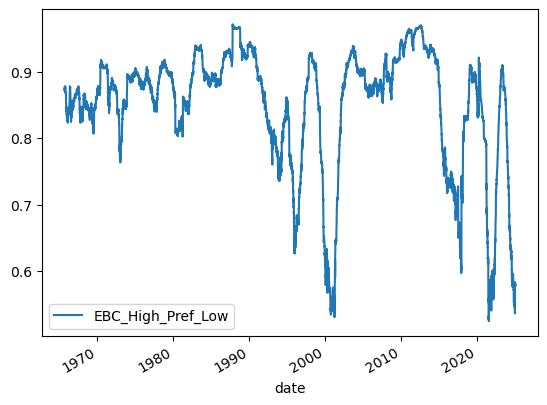

In [101]:
temp_df[temp_df['level_1']== 'CW'].set_index('date').plot()

In [97]:
quantile_portfolios_returns.corr()

,EBC_High_Pref_High,EBC_High_Pref_Mid,EBC_High_Pref_Low,EBC_Mid_Pref_High,EBC_Mid_Pref_Mid,EBC_Mid_Pref_Low,EBC_Low_Pref_High,EBC_Low_Pref_Mid,EBC_Low_Pref_Low
EBC_High_Pref_High,1.000000,0.860080,0.780711,0.840175,0.788790,0.734596,0.694241,0.637161,0.568600
EBC_High_Pref_Mid,0.860080,1.000000,0.900967,0.809205,0.882105,0.851909,0.703611,0.731136,0.685636
EBC_High_Pref_Low,0.780711,0.900967,1.000000,0.745351,0.863820,0.885375,0.656932,0.721817,0.700010
EBC_Mid_Pref_High,0.840175,0.809205,0.745351,1.000000,0.830871,0.749508,0.845104,0.723082,0.626217
EBC_Mid_Pref_Mid,0.788790,0.882105,0.863820,0.830871,1.000000,0.886966,0.774686,0.825405,0.760422
EBC_Mid_Pref_Low,0.734596,0.851909,0.885375,0.749508,0.886966,1.000000,0.701443,0.803421,0.785056
EBC_Low_Pref_High,0.694241,0.703611,0.656932,0.845104,0.774686,0.701443,1.000000,0.766800,0.662822
EBC_Low_Pref_Mid,0.637161,0.731136,0.721817,0.723082,0.825405,0.803421,0.766800,1.000000,0.826812
EBC_Low_Pref_Low,0.568600,0.685636,0.700010,0.626217,0.760422,0.785056,0.662822,0.826812,1.000000


In [102]:
quantile_portfolios_returns.index.name = "date"

In [103]:
save_dir = DATA_PROCESSED_DIR / 'daily'

In [104]:
quantile_portfolios_returns.to_csv(save_dir / "daily_quantile_returns_3x3.csv")

# <span style="color:red">  Fitted GARCH

In [105]:
from arch import arch_model
import numpy as np
import matplotlib.pyplot as plt


In [106]:
def fit_garch_model(returns):
    """
    Fit GARCH(1,1) with student t errors
    """

    returns = returns.dropna()

    # Scale to percentage
    returns_scaled = returns * 100

    am = arch_model(
        returns_scaled,
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="t"
    )

    res = am.fit(disp="off")

    return res


In [107]:
complete_df.columns

Index(['CW', 'EW', 'EBC', 'MKT_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'MOM',
       'CW-EW', 'CW-EBC', 'EBC_High_Pref_High', 'EBC_High_Pref_Mid',
       'EBC_High_Pref_Low', 'EBC_Mid_Pref_High', 'EBC_Mid_Pref_Mid',
       'EBC_Mid_Pref_Low', 'EBC_Low_Pref_High', 'EBC_Low_Pref_Mid',
       'EBC_Low_Pref_Low'],
      dtype='object')

In [111]:
portfolio_name = 'CW'

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                           CW   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -18829.7
Distribution:      Standardized Student's t   AIC:                           37669.4
Method:                  Maximum Likelihood   BIC:                           37707.5
                                              No. Observations:                15185
Date:                      Thu, Feb 26 2026   Df Residuals:                    15184
Time:                              11:14:33   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

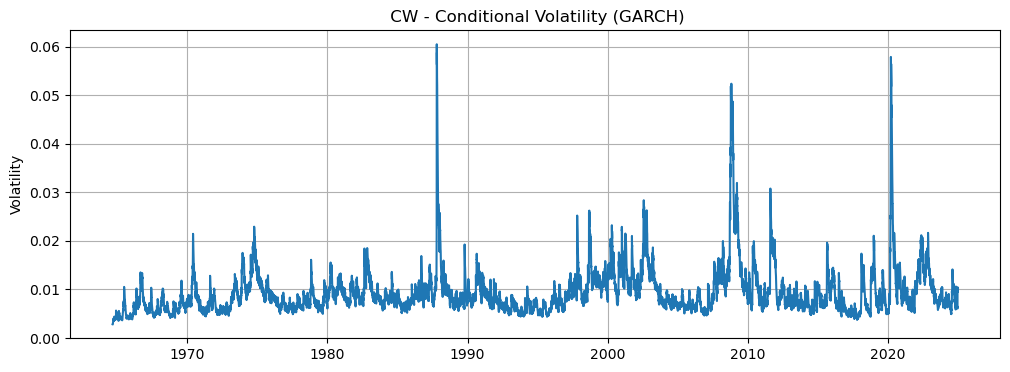

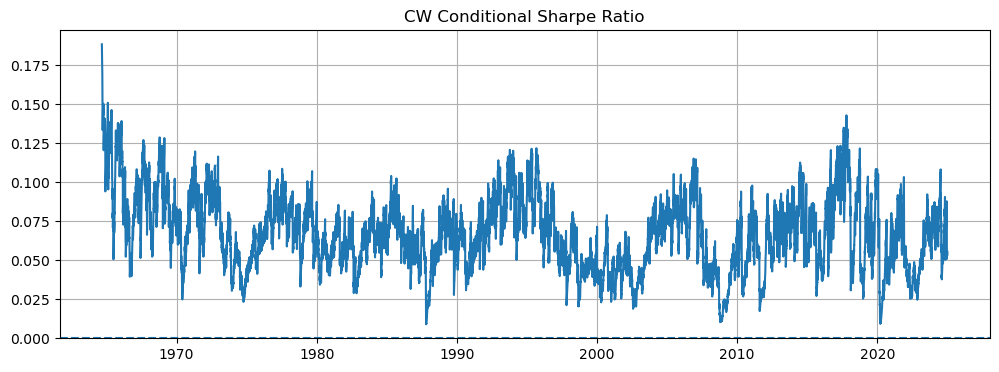

In [112]:
portfolio = complete_df[portfolio_name]

garch_res = fit_garch_model(portfolio)

print(garch_res.summary())


cond_vol = garch_res.conditional_volatility / 100  # scale back

plt.figure(figsize=(12,4))
plt.plot(cond_vol)
plt.title(f" {portfolio_name} - Conditional Volatility (GARCH)")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

mean_return = portfolio.mean()

cond_sharpe = mean_return / cond_vol

plt.figure(figsize=(12,4))
plt.plot(cond_sharpe)
plt.axhline(0, linestyle="--")
plt.title(f"{portfolio_name} Conditional Sharpe Ratio")
plt.grid(True)
plt.show()





                        Constant Mean - GARCH Model Results                         
Dep. Variable:            EBC_High_Pref_Low   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -23317.2
Distribution:      Standardized Student's t   AIC:                           46644.3
Method:                  Maximum Likelihood   BIC:                           46682.5
                                              No. Observations:                15185
Date:                      Thu, Feb 26 2026   Df Residuals:                    15184
Time:                              11:14:34   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

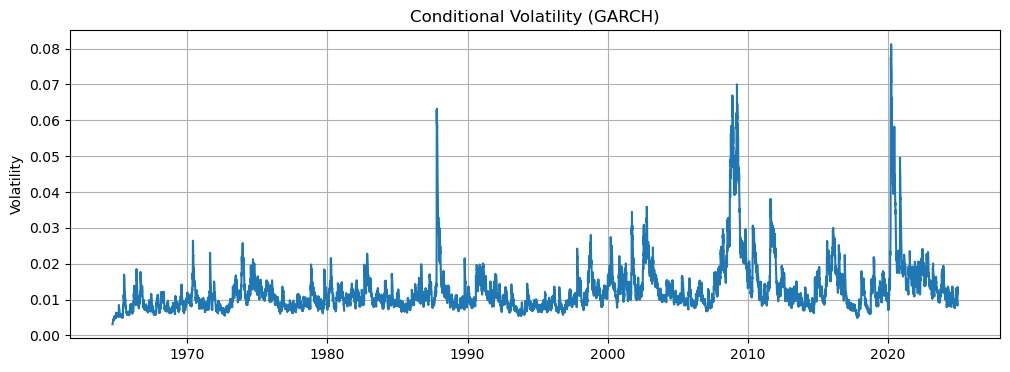

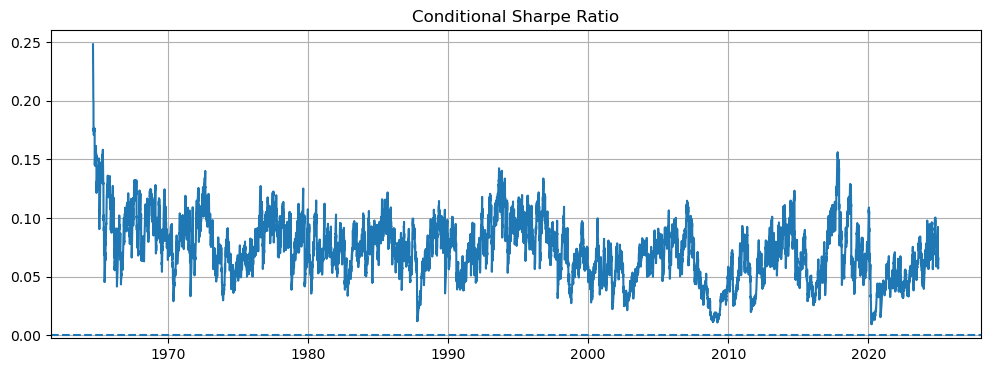

In [113]:
portfolio = complete_df["EBC_High_Pref_Low"]

garch_res = fit_garch_model(portfolio)

print(garch_res.summary())


cond_vol = garch_res.conditional_volatility / 100  # scale back

plt.figure(figsize=(12,4))
plt.plot(cond_vol)
plt.title("Conditional Volatility (GARCH)")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

mean_return = portfolio.mean()

cond_sharpe = mean_return / cond_vol

plt.figure(figsize=(12,4))
plt.plot(cond_sharpe)
plt.axhline(0, linestyle="--")
plt.title("Conditional Sharpe Ratio")
plt.grid(True)
plt.show()



